Simulation complete. Check 'protein_sim.png' for the stability profile.


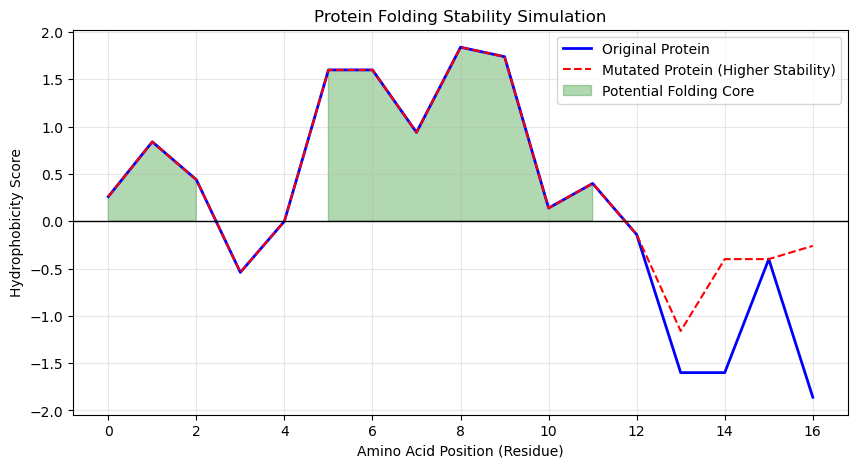

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Hydrophobicity Scale (Kyte-Doolittle)
# Higher positive values = more hydrophobic (hates water)
kd_scale = {
    'I': 4.5, 'V': 4.2, 'L': 3.8, 'F': 2.8, 'C': 2.5, 'M': 1.9, 'A': 1.8,
    'G': -0.4, 'T': -0.7, 'S': -0.8, 'W': -0.9, 'Y': -1.3, 'P': -1.6,
    'H': -3.2, 'E': -3.5, 'Q': -3.5, 'D': -3.5, 'N': -3.5, 'K': -3.9, 'R': -4.5
}

# 2. A sample protein sequence (Insulin Alpha Chain)
sequence = "GIVEQCCTSICSLYQLENYCN"

def simulate_folding_potential(seq, window_size=5):
    # Convert sequence to numerical values
    values = [kd_scale.get(aa, 0) for aa in seq]
    
    # Calculate a moving average (Sliding Window)
    # This simulates how local clusters of amino acids behave together
    scores = np.convolve(values, np.ones(window_size)/window_size, mode='valid')
    
    return scores

# 3. Simulate a "Mutation"
# Let's change a Hydrophilic 'N' (Asn) to a Hydrophobic 'I' (Ile)
mutated_sequence = "GIVEQCCTSICSLYQLEYCNI" 

original_scores = simulate_folding_potential(sequence)
mutated_scores = simulate_folding_potential(mutated_sequence)

# 4. Plotting the result
plt.figure(figsize=(10, 5))
plt.plot(original_scores, label='Original Protein', color='blue', linewidth=2)
plt.plot(mutated_scores, label='Mutated Protein (Higher Stability)', color='red', linestyle='--')

plt.axhline(0, color='black', lw=1, ls='-')
plt.fill_between(range(len(original_scores)), original_scores, where=(original_scores > 0), color='green', alpha=0.3, label="Potential Folding Core")

plt.title("Protein Folding Stability Simulation")
plt.xlabel("Amino Acid Position (Residue)")
plt.ylabel("Hydrophobicity Score")
plt.legend()
plt.grid(True, alpha=0.3)

# Save the plot since you are on Ubuntu Server
plt.savefig('protein_sim.png')
print("Simulation complete. Check 'protein_sim.png' for the stability profile.")